In [ ]:
import pandas as pd

covid_df = pd.read_csv('data/covid_df.csv')
! pip install matplotlib

In [ ]:
# # Создание признака death_rate
# covid_df['death_rate'] = (covid_df['deaths'] / covid_df['confirmed']) * 100

# # Создание признака recover_rate
# covid_df['recover_rate'] = (covid_df['recovered'] / covid_df['confirmed']) * 100

# # Просмотр первых строк таблицы с новыми признаками
# print(covid_df[['date', 'country', 'death_rate', 'recover_rate']].head())


         date      country  death_rate  recover_rate
0  2020-02-24  Afghanistan         0.0           0.0
1  2020-02-25  Afghanistan         0.0           0.0
2  2020-02-26  Afghanistan         0.0           0.0
3  2020-02-27  Afghanistan         0.0           0.0
4  2020-02-28  Afghanistan         0.0           0.0


In [ ]:
print(covid_df.info())

In [4]:
# Выполнено Агрегаты: 2 с группированием по столбцу 'country'
country_df = covid_df.groupby(['country']).agg(death_rate_mean=('death_rate', 'mean'), recover_rate_mean=('recover_rate', 'mean')).reset_index()

In [7]:
display(country_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            221 non-null    object 
 1   death_rate_mean    221 non-null    float64
 2   recover_rate_mean  221 non-null    float64
dtypes: float64(2), object(1)
memory usage: 5.3+ KB


None

Таблица данных в виде Heatmap (тепловой карты):

Используйте тепловую карту, чтобы показать зависимость средней смертности (death_rate_mean) и средней выздоравливаемости (recover_rate_mean) по странам.

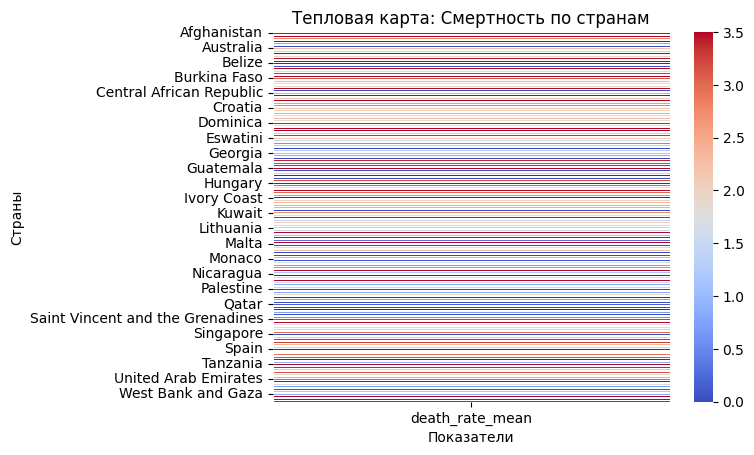

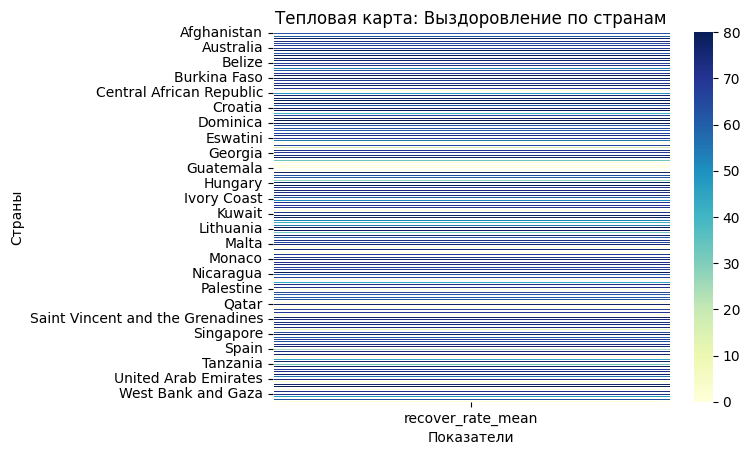

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Создание тепловой карты
pivot_table = country_df.pivot_table(index='country', values=['death_rate_mean'])
# Настройка диапазонов для death_rate_mean и recover_rate_mean
sns.heatmap(
    pivot_table, 
    cmap='coolwarm', 
    annot=False, 
    linewidths=0.5, 
    vmin=0, 
    vmax=3.5  # Для death_rate_mean
)


# Создание тепловой карты
pivot_table = country_df.pivot_table(index='country', values=['recover_rate_mean'])

# Настройки графика для death_rate_mean
plt.title('Тепловая карта: Смертность по странам')
plt.xlabel('Показатели')
plt.ylabel('Страны')
plt.show()

# Отдельная тепловая карта для recover_rate_mean
sns.heatmap(
    pivot_table, 
    cmap='YlGnBu', 
    annot=False, 
    linewidths=0.5, 
    vmin=0, 
    vmax=80.0  # Для recover_rate_mean
)

# Настройки графика для recover_rate_mean
plt.title('Тепловая карта: Выздоровление по странам')
plt.xlabel('Показатели')
plt.ylabel('Страны')
plt.show()

Гистограммы:

Постройте две отдельные гистограммы для показателей средней смертности и выздоровления.

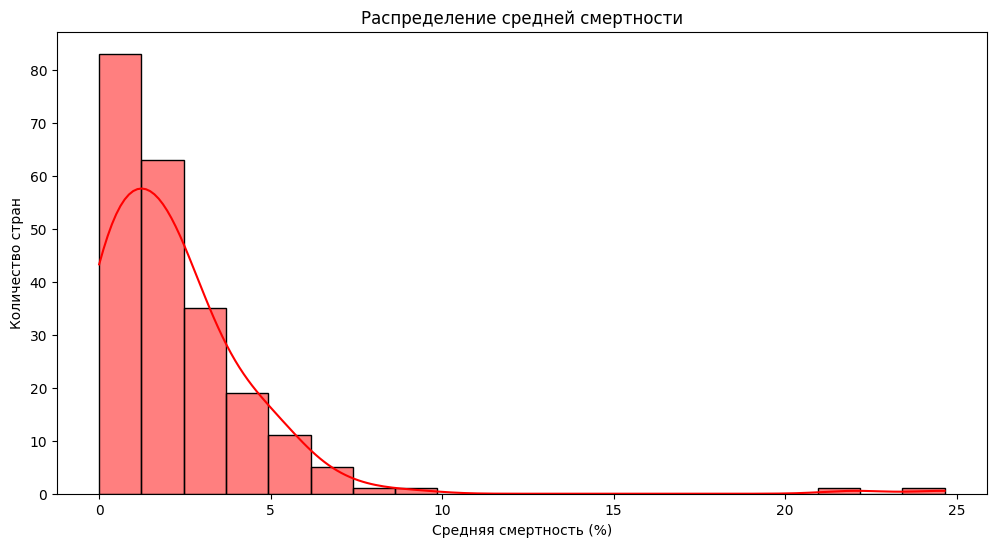

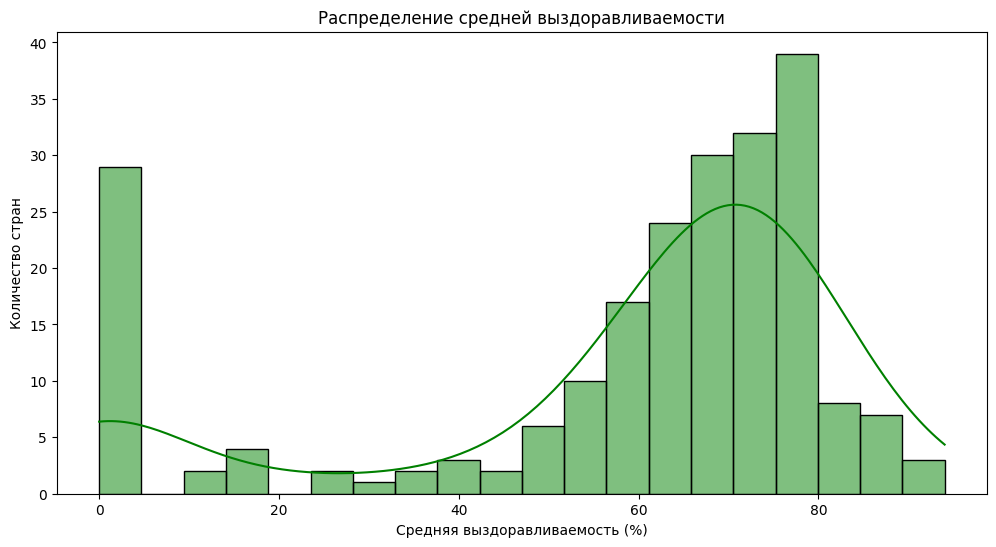

In [20]:
# Гистограмма для средней смертности
plt.figure(figsize=(12, 6))
sns.histplot(data=country_df, x='death_rate_mean', bins=20, kde=True, color='red')
plt.title('Распределение средней смертности')
plt.xlabel('Средняя смертность (%)')
plt.ylabel('Количество стран')
plt.show()

# Гистограмма для средней выздоравливаемости
plt.figure(figsize=(12, 6))
sns.histplot(data=country_df, x='recover_rate_mean', bins=20, kde=True, color='green')
plt.title('Распределение средней выздоравливаемости')
plt.xlabel('Средняя выздоравливаемость (%)')
plt.ylabel('Количество стран')
plt.show()


Горизонтальная столбчатая диаграмма для сравнения:

Покажите топ стран с наибольшей смертностью или выздоравливаемостью.

C:\Users\makss\AppData\Local\Temp\ipykernel_3172\4157528945.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='death_rate_mean', y='country', palette='Reds_r')


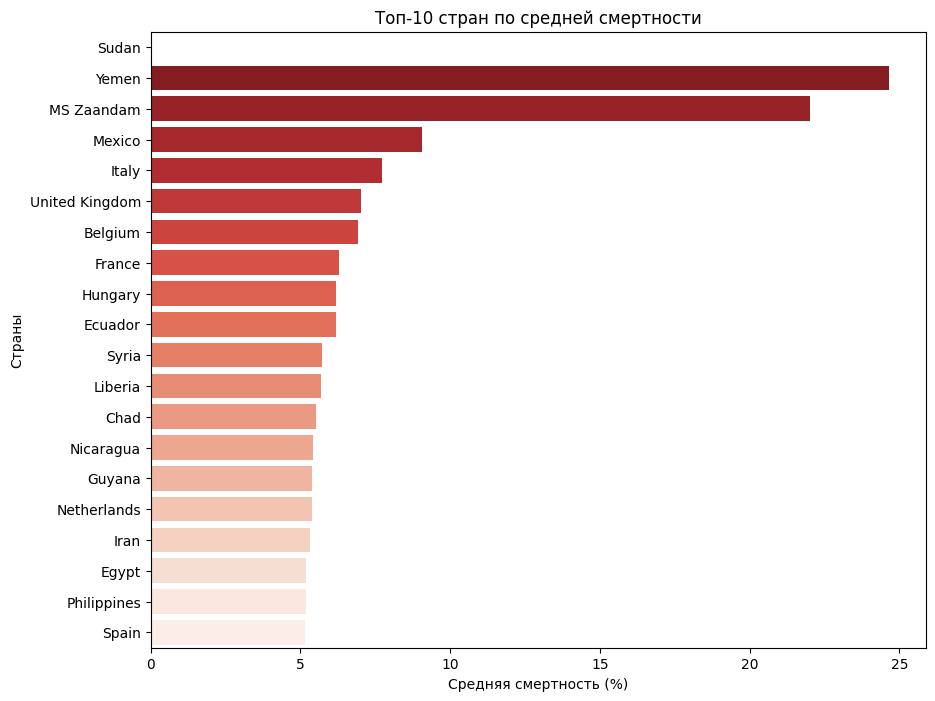

C:\Users\makss\AppData\Local\Temp\ipykernel_3172\4157528945.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='recover_rate_mean', y='country', palette='Greens_r')


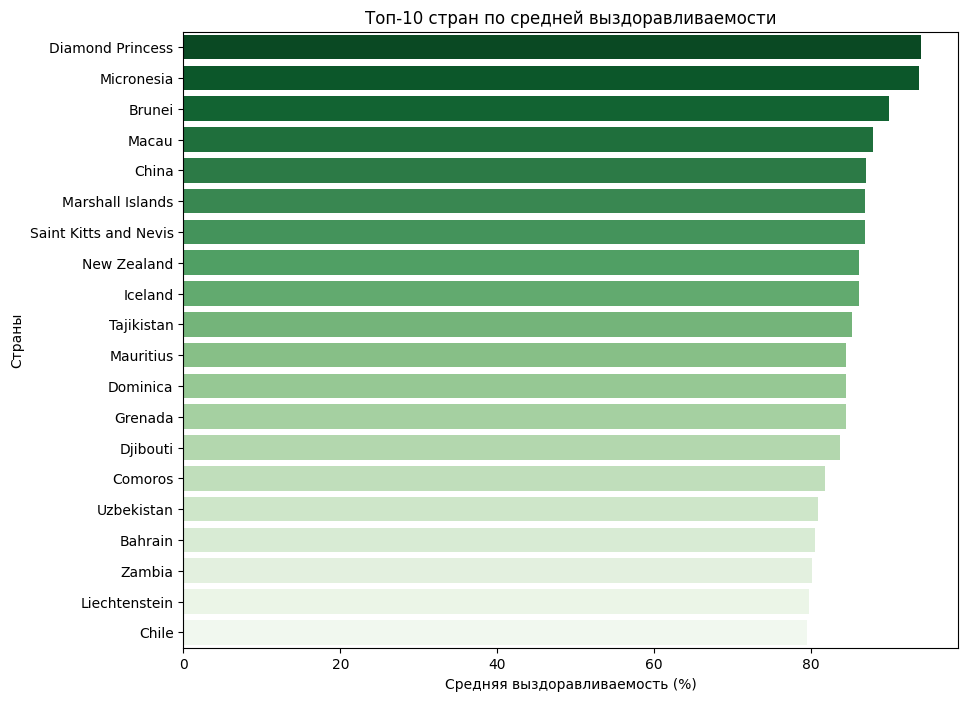

In [25]:
# Сортируем данные по средней смертности
top_countries = country_df.sort_values('death_rate_mean', ascending=False).head(20)

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 8))
sns.barplot(data=top_countries, x='death_rate_mean', y='country', palette='Reds_r')
plt.title('Топ-10 стран по средней смертности')
plt.xlabel('Средняя смертность (%)')
plt.ylabel('Страны')
plt.show()


# Сортируем данные по средней смертности
top_countries = country_df.sort_values('recover_rate_mean', ascending=False).head(20)

# Построение столбчатой диаграммы
plt.figure(figsize=(10, 8))
sns.barplot(data=top_countries, x='recover_rate_mean', y='country', palette='Greens_r')
plt.title('Топ-10 стран по средней выздоравливаемости')
plt.xlabel('Средняя выздоравливаемость (%)')
plt.ylabel('Страны')
plt.show()

In [5]:
# Сохранение таблицы в файл CSV
covid_df.to_csv('data/covid_df.csv', index=False)

print("Таблица успешно сохранена в файл 'covid_df.csv'.")

Таблица успешно сохранена в файл 'covid_df.csv'.
